Import the libraries and models for Logistic Regression

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score,f1_score,confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler

Load titanic Datasets

In [3]:
#import data
df = sns.load_dataset("titanic")
df.head()
df.isnull().sum().sort_values()

survived         0
pclass           0
sex              0
sibsp            0
fare             0
parch            0
who              0
class            0
alone            0
alive            0
adult_male       0
embarked         2
embark_town      2
age            177
deck           688
dtype: int64

Fill the null values by using mean and mode 

In [13]:
# data pre processing 
# remove the deck column
df.drop('deck', axis=1, inplace=True, errors='ignore')
#impute the missing values from age and fare column
df['age'].fillna(df['age'].median(), inplace=True)
df['fare'].fillna(df['fare'].median(), inplace=True)

#impute the missing in embarked and embarked_town
df['embark_town'].fillna(df['embark_town'].mode()[0], inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0],inplace = True)

C:\Users\Abu bakar\AppData\Local\Temp\ipykernel_6884\1870529527.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
C:\Users\Abu bakar\AppData\Local\Temp\ipykernel_6884\1870529527.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


Encode the object and categoy data type from categorical data to numeric data

In [5]:
# encode the categorical variable by using the for loop from where the object and category datatypes are given
encode = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype =='category' :
        df[col] = encode.fit_transform(df[col])

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,True,2,0,False
1,1,1,0,38.0,1,0,71.2833,0,0,2,False,0,1,False
2,1,3,0,26.0,0,0,7.9250,2,2,2,False,2,1,True
3,1,1,0,35.0,1,0,53.1000,2,0,2,False,2,1,False
4,0,3,1,35.0,0,0,8.0500,2,2,1,True,2,0,True


In [6]:
df.isnull().sum().sort_values()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Add Features and labels

In [7]:
# X and y x column
X = df.drop('survived',axis=1)
y = df['survived']

split the data by using train_test_split model with 80% training and 20% testing

In [8]:
# train test split the data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

Call the model and fit that

In [9]:
# call the model
model = LogisticRegression()

# Train the model
model.fit(X_train,y_train)

c:\Users\Abu bakar\anaconda3\envs\python_ml\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Predict the model and evaluate the model how much accuracy

In [10]:
# predict the values 
y_predict = model.predict(X_test)

# evaluate the model
print('Accuracy score : ',accuracy_score(y_test,y_predict))
print("Recall score : ",recall_score(y_test,y_predict))
print("Precision score : ",precision_score(y_test,y_predict))
print("F1 score : ",f1_score(y_test,y_predict))
print("Confiusion metrics : ",confusion_matrix(y_test,y_predict))
print("Classification reports : ",classification_report(y_test,y_predict))

Accuracy score :  1.0
Recall score :  1.0
Precision score :  1.0
F1 score :  1.0
Confiusion metrics :  [[105   0]
 [  0  74]]
Classification reports :                precision    recall  f1-score   support

           0       1.00      1.00      1.00       105
           1       1.00      1.00      1.00        74

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



Plot the confusion metrix with heatmap

Text(33.22222222222222, 0.5, 'Actual')

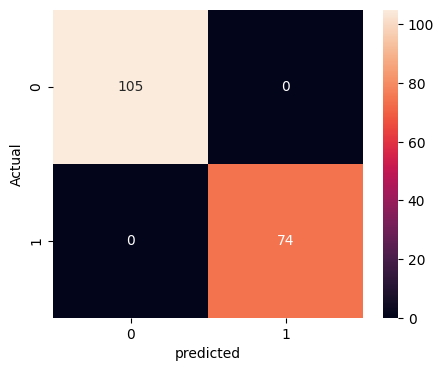

In [11]:
# plot the confiusion metrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test,y_predict),annot=True ,fmt='d')
plt.xlabel('predicted')
plt.ylabel('Actual')

save the model

In [15]:
# save the model 
import pickle
pickle.dump(model,open('../saved_models/logistic_regression.pkl','wb'))